# KNN Classification & Regression on Spotify Dataset
- **Classification:** Predict `track_genre` using audio features
- **Regression:** Predict `popularity` score using audio features

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## 2. Load & Preview Data

In [2]:
df = pd.read_csv('spotify.csv')
print('Shape:', df.shape)
df.head()

Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


## 3. Preprocessing

In [4]:
# Drop nulls, duplicates, and non-feature columns
df.dropna(inplace=True)
df.drop_duplicates(subset='track_id', inplace=True)
df.drop(columns=['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name'], inplace=True)
df['explicit'] = df['explicit'].astype(int)

# Use top 5 genres to keep classification manageable
top5 = df['track_genre'].value_counts().head(5).index
df = df[df['track_genre'].isin(top5)].reset_index(drop=True)

print('Working shape:', df.shape)
print('Genres:', df['track_genre'].unique())

Working shape: (4996, 16)
Genres: <StringArray>
['acoustic', 'afrobeat', 'alt-rock', 'ambient', 'cantopop']
Length: 5, dtype: str


In [5]:
# Define features and target
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

X = df[features]
le = LabelEncoder()
y = le.fit_transform(df['track_genre'])

print('Classes:', le.classes_)

Classes: ['acoustic' 'afrobeat' 'alt-rock' 'ambient' 'cantopop']


## 4. EDA

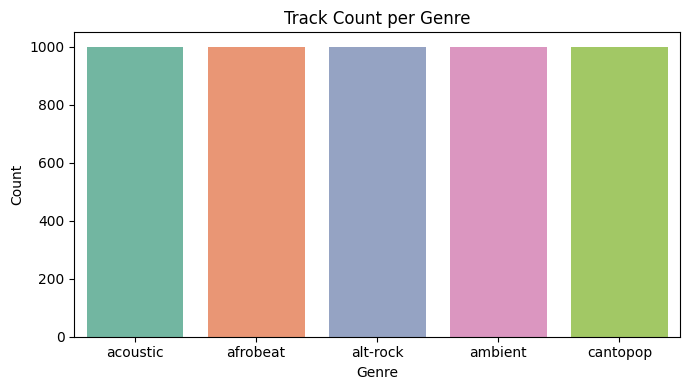

In [6]:
# Class distribution
plt.figure(figsize=(7, 4))
sns.countplot(x='track_genre', data=df, palette='Set2')
plt.title('Track Count per Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

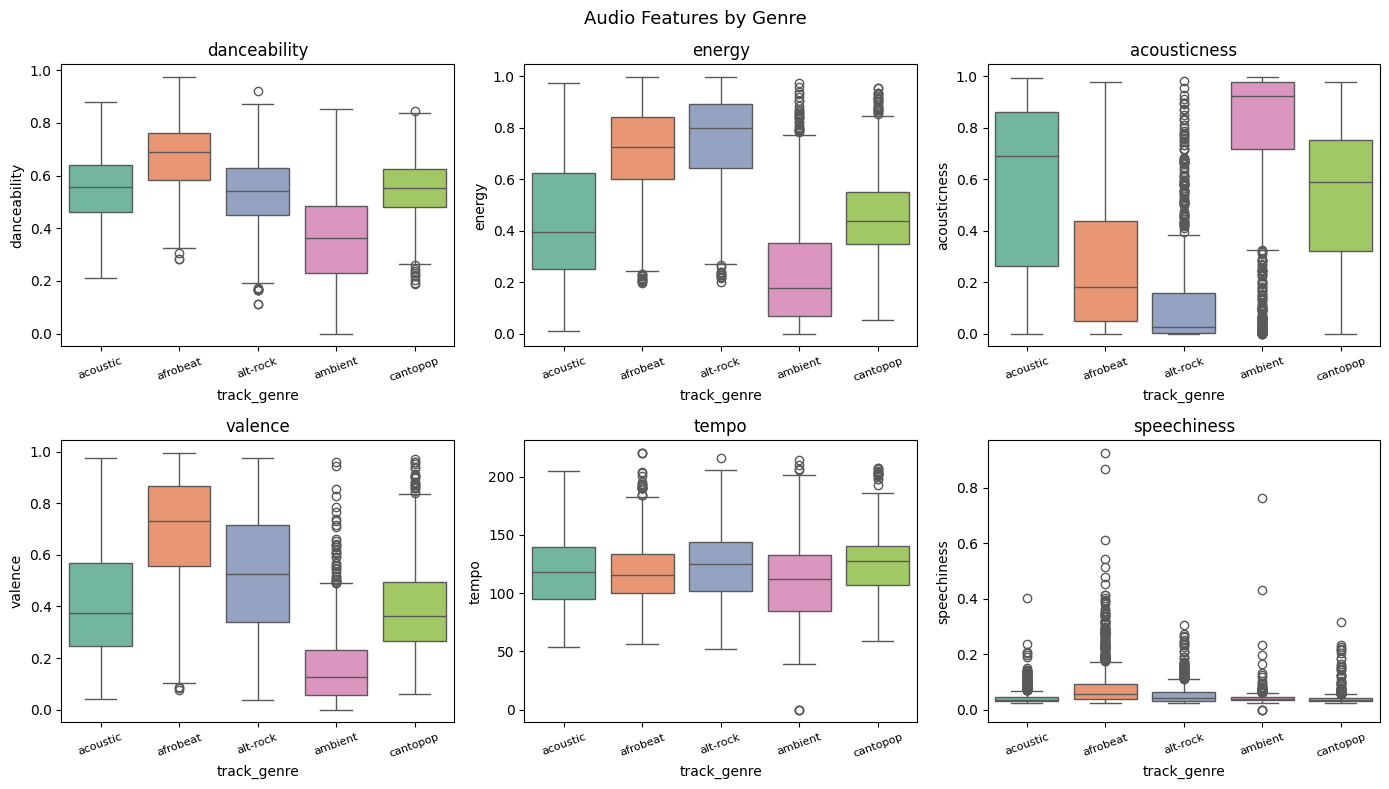

In [7]:
# Boxplots of key features by genre
plt.figure(figsize=(14, 8))
for i, feat in enumerate(['danceability', 'energy', 'acousticness', 'valence',
                           'tempo', 'speechiness'], 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='track_genre', y=feat, data=df, palette='Set2')
    plt.xticks(rotation=20, fontsize=8)
    plt.title(feat)
plt.suptitle('Audio Features by Genre', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Train-Test Split & Scaling

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (3996, 9) | Test: (1000, 9)


## 6. Find Optimal K

In [9]:
f1_scores = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    from sklearn.metrics import f1_score
    f1_scores.append(f1_score(y_test, pred, average='macro'))
    print(f'K={k:2d} | F1 Score: {f1_scores[-1]:.4f}')

K= 1 | F1 Score: 0.5988
K= 2 | F1 Score: 0.5941
K= 3 | F1 Score: 0.6219


K= 4 | F1 Score: 0.6212


K= 5 | F1 Score: 0.6283
K= 6 | F1 Score: 0.6264
K= 7 | F1 Score: 0.6256


K= 8 | F1 Score: 0.6395


K= 9 | F1 Score: 0.6362
K=10 | F1 Score: 0.6304
K=11 | F1 Score: 0.6276


...

K=13 | F1 Score: 0.6216
K=14 | F1 Score: 0.6268


K=15 | F1 Score: 0.6312


K=16 | F1 Score: 0.6240
K=17 | F1 Score: 0.6270


K=18 | F1 Score: 0.6248


K=19 | F1 Score: 0.6282
K=20 | F1 Score: 0.6291


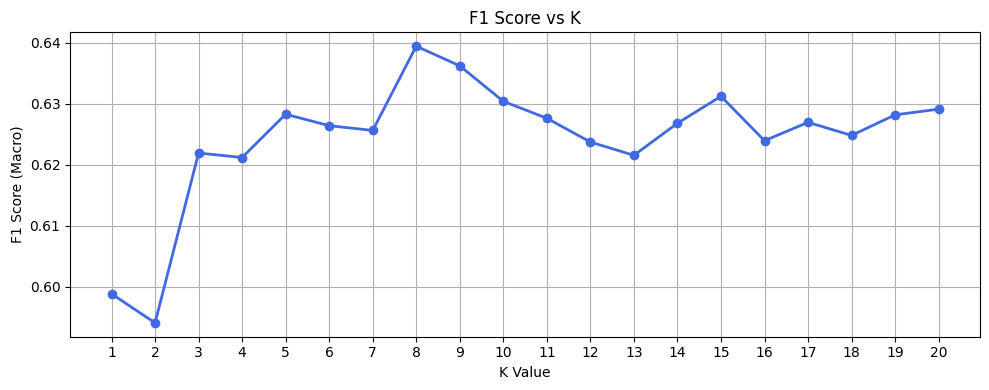

Best K = 8 | Best F1 = 0.6395


In [10]:
plt.figure(figsize=(10, 4))
plt.plot(list(k_range), f1_scores, marker='o', color='royalblue', linewidth=2)
plt.xlabel('K Value')
plt.ylabel('F1 Score (Macro)')
plt.title('F1 Score vs K')
plt.xticks(list(k_range))
plt.grid(True)
plt.tight_layout()
plt.show()

best_k = list(k_range)[f1_scores.index(max(f1_scores))]
print(f'Best K = {best_k} | Best F1 = {max(f1_scores):.4f}')

## 7. Train Final Model & Evaluate

In [11]:
knn_final = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}\n')
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.6350

Classification Report:
              precision    recall  f1-score   support

    acoustic       0.44      0.49      0.47       200
    afrobeat       0.73      0.70      0.71       200
    alt-rock       0.61      0.62      0.61       200
     ambient       0.86      0.76      0.81       200
    cantopop       0.59      0.60      0.60       200

    accuracy                           0.64      1000
   macro avg       0.65      0.64      0.64      1000
weighted avg       0.65      0.64      0.64      1000



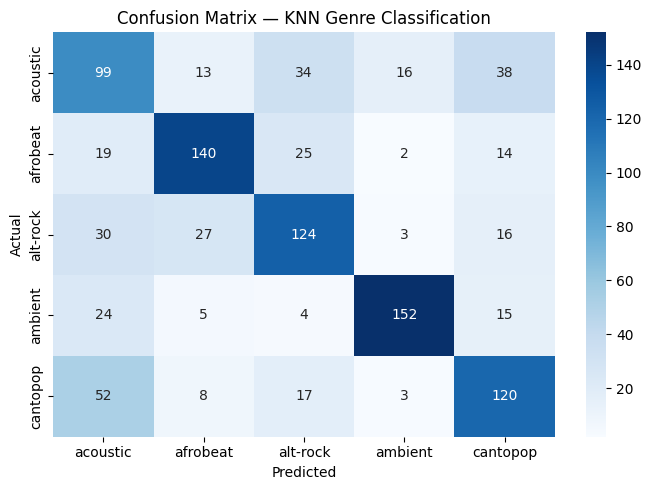

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — KNN Genre Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

---
# PART 2 — KNN Regression
**Goal:** Predict `popularity` score (0–100) using audio features

## 8. Prepare Regression Data

In [13]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

# Reload full dataset for regression (all genres)
df_reg = pd.read_csv('spotify.csv')
df_reg.dropna(inplace=True)
df_reg.drop_duplicates(subset='track_id', inplace=True)
df_reg.drop(columns=['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name'], inplace=True)
df_reg['explicit'] = df_reg['explicit'].astype(int)

print('Shape:', df_reg.shape)
print('Popularity stats:')
print(df_reg['popularity'].describe())

Shape: (89740, 16)
Popularity stats:
count    89740.000000
mean        33.198808
std         20.580640
min          0.000000
25%         19.000000
50%         33.000000
75%         49.000000
max        100.000000
Name: popularity, dtype: float64


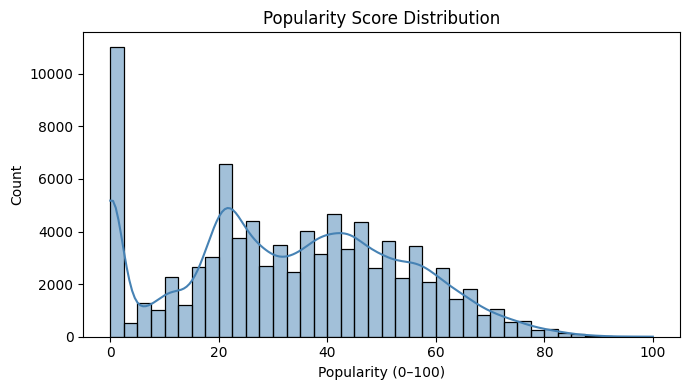

In [14]:
# Features and target
reg_features = ['danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

X_r = df_reg[reg_features]
y_r = df_reg['popularity']

# Popularity distribution
plt.figure(figsize=(7, 4))
sns.histplot(y_r, bins=40, kde=True, color='steelblue')
plt.title('Popularity Score Distribution')
plt.xlabel('Popularity (0–100)')
plt.tight_layout()
plt.show()

## 9. Train-Test Split & Scaling

In [15]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
)

scaler_r = StandardScaler()
X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r  = scaler_r.transform(X_test_r)

print(f'Train: {X_train_r.shape} | Test: {X_test_r.shape}')

Train: (71792, 9) | Test: (17948, 9)


## 10. Find Optimal K via RMSE

In [16]:
rmse_list = []
k_range_r = range(1, 21)

for k in k_range_r:
    knn_r = KNeighborsRegressor(n_neighbors=k)
    knn_r.fit(X_train_r, y_train_r)
    pred_r = knn_r.predict(X_test_r)
    rmse = sqrt(mean_squared_error(y_test_r, pred_r))
    rmse_list.append(rmse)
    print(f'K={k:2d} | RMSE: {rmse:.4f}')

K= 1 | RMSE: 24.9667


K= 2 | RMSE: 22.2019


K= 3 | RMSE: 21.0824


K= 4 | RMSE: 20.6273


K= 5 | RMSE: 20.3313


...

K=16 | RMSE: 19.5781


K=17 | RMSE: 19.5688


K=18 | RMSE: 19.5676


K=19 | RMSE: 19.5553


K=20 | RMSE: 19.5467


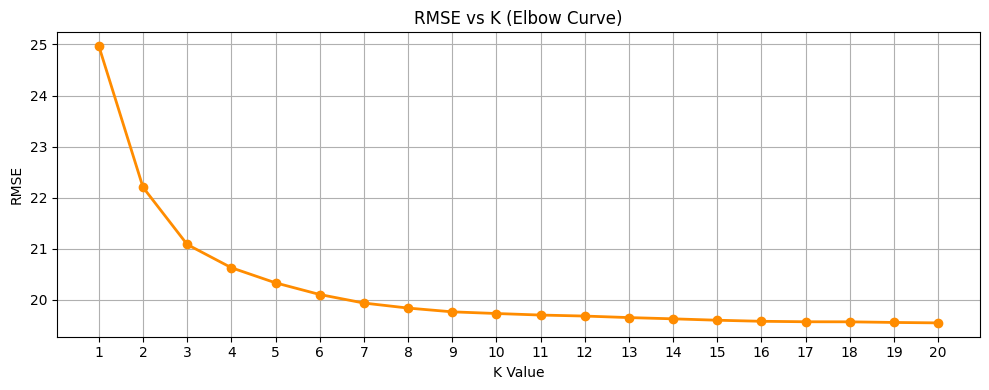

Best K = 20 | Lowest RMSE = 19.5467


In [17]:
plt.figure(figsize=(10, 4))
plt.plot(list(k_range_r), rmse_list, marker='o', color='darkorange', linewidth=2)
plt.xlabel('K Value')
plt.ylabel('RMSE')
plt.title('RMSE vs K (Elbow Curve)')
plt.xticks(list(k_range_r))
plt.grid(True)
plt.tight_layout()
plt.show()

best_k_r = list(k_range_r)[rmse_list.index(min(rmse_list))]
print(f'Best K = {best_k_r} | Lowest RMSE = {min(rmse_list):.4f}')

## 11. Train Final Model & Evaluate

In [18]:
knn_reg_final = KNeighborsRegressor(n_neighbors=best_k_r)
knn_reg_final.fit(X_train_r, y_train_r)
y_pred_r = knn_reg_final.predict(X_test_r)

print('=== Regression Metrics ===')
print(f'R² Score : {r2_score(y_test_r, y_pred_r):.4f}')
print(f'MAE      : {mean_absolute_error(y_test_r, y_pred_r):.4f}')
print(f'RMSE     : {sqrt(mean_squared_error(y_test_r, y_pred_r)):.4f}')

=== Regression Metrics ===
R² Score : 0.0865
MAE      : 15.5808
RMSE     : 19.5467


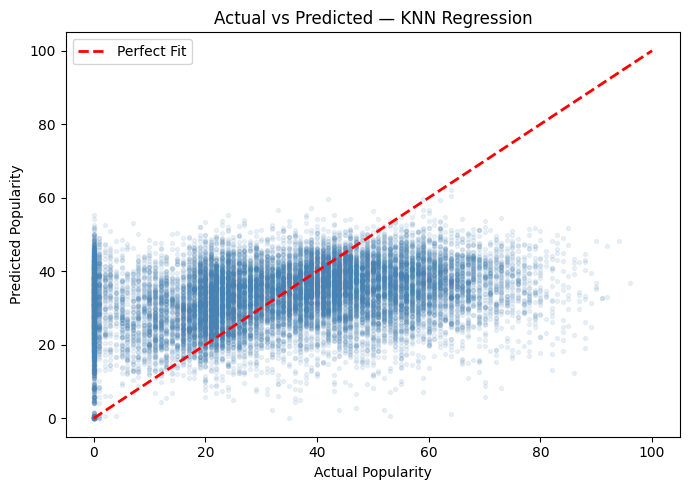

In [19]:
# Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test_r, y_pred_r, alpha=0.1, s=8, color='steelblue')
plt.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Fit')
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Actual vs Predicted — KNN Regression')
plt.legend()
plt.tight_layout()
plt.show()

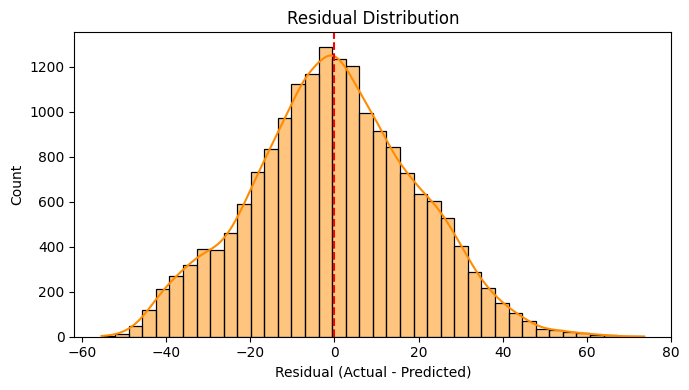

In [20]:
# Residual plot
residuals = y_test_r - y_pred_r
plt.figure(figsize=(7, 4))
sns.histplot(residuals, bins=40, kde=True, color='darkorange')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residual Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()